# Tarea Semanal 3
## Autor: Pedro Guzman


### Consigna 
En esta tarea simularemos el comportamiento de un ADC y cómo sus parámetros, tamaño de palabra de B bits y frecuencia de muestreo fs afectan a una señal (aproximadamente) analógica.

Para ello se puede analizar una senoidal con los siguientes parámetros:

* frecuencia arbitraria, por ejemplo $f_0 = f_S/N = \Delta_f$
*  Potencia normalizada, es decir unitaria
Se pide diseñar un bloque cuantizador que opere sobre una señal discreta en tiempo  $s_R$, de forma tal que para un ADC de B bits y rango $V_{FS} = 2.V_F$, el operador.

 
$s_Q = \mathop{Q}_{B,V_{FS}}  \{s_R\}$

generará una $s_Q$ comprendida entre $\pm V_F$ y con valores discretos establecidos por el paso de cuantización $q = \frac{V_{FS}}{2^B}$ (Volts).

Visualice en una misma gráfica $s_R $ y $s_Q$  , donde se pueda observar que tienen el mismo rango en Volts y el efecto de la cuantización para 
 $V_F = 2$Volts y  B = 4, 8 y 16 bits.

### Bonus:
🤯 Analizar la señal de error $e = s_Q - s_R$ verificando las descripciones estadísticas vistas en teoría (Distribución uniforme, media, varianza, incorrelación)
 



### Solucion Propuesta

In [1]:
import matplotlib.pyplot as plt

import numpy as np
import scipy.signal as sp
import time
from scipy.fft import fft, ifft

In [2]:
#Funcion del generador de se;ales
def  mi_funcion ( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 50, type_s = 'sine', duty = 0.5, vmed=5e-3, vsigma=0.5e-3) :
    
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    if   type_s == 'sine' :
        xx = vmax*np.sin(2*np.pi*ff*tt+ph)+dc
    elif type_s == 'sawtooth' :
        xx = vmax*sp.sawtooth(2*np.pi*ff*tt+ph)+dc
    elif type_s == 'triangle' :
        xx = vmax*sp.sawtooth(2*np.pi*ff*tt+ph,width = 0.5)+dc
    elif type_s == 'invsawtooth' :
        xx = vmax*sp.sawtooth(2*np.pi*ff*tt+ph, width = 0)+dc
    elif type_s == 'square' :
        xx = vmax*sp.square(2*np.pi*ff*tt+ph, duty = duty)+dc
    elif type_s == 'noise' :
        xx = np.random.normal(vmed, vsigma, len(tt))+dc
    else :
        print("Tipo de funcion no existente o incorrecta")
    
    return tt, xx

def Quant(VFS, x, B) :
    
    q = VFS/(2**B)
    SQ = np.round(x/q)*q
    SQ = np.clip(SQ,a_min=-q*(2**(B-1)) , a_max=q*(2**(B-1)-1))
    print(f"Cuanto={q} para Vref={VFS} y cantidad de bits = {B}")
    return SQ

def  mi_generador_ruidoso ( Psine = 1,R = 1 ,SNRdB=10, ff = 1, ph = 0, nn = 100, fs = 50) :
    vmax=np.sqrt(Psine*2*R)
    Pnoise=Psine/(10**(SNRdB/10))
    vsigma=np.sqrt(Pnoise*R)
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    _, xx_sine = mi_funcion( vmax = vmax, dc = 0, ff = ff, ph= ph, nn = nn, fs = fs, type_s = 'sine')
    _ ,xx_noise = mi_funcion( vmed = 0, vsigma = vsigma, nn = nn, fs = fs, type_s = 'noise')
    xx= xx_sine + xx_noise
    SNR_real = 10 * np.log10(Psine / np.var(xx_noise))
    print(f"SNR real: {SNR_real:.9f} dB")
    return tt, xx, xx_sine , xx_noise


####  B = 4, 8 y 16 bits.

Cuanto=0.25 para Vref=4 y cantidad de bits = 4
Cuanto=0.015625 para Vref=4 y cantidad de bits = 8
Cuanto=6.103515625e-05 para Vref=4 y cantidad de bits = 16


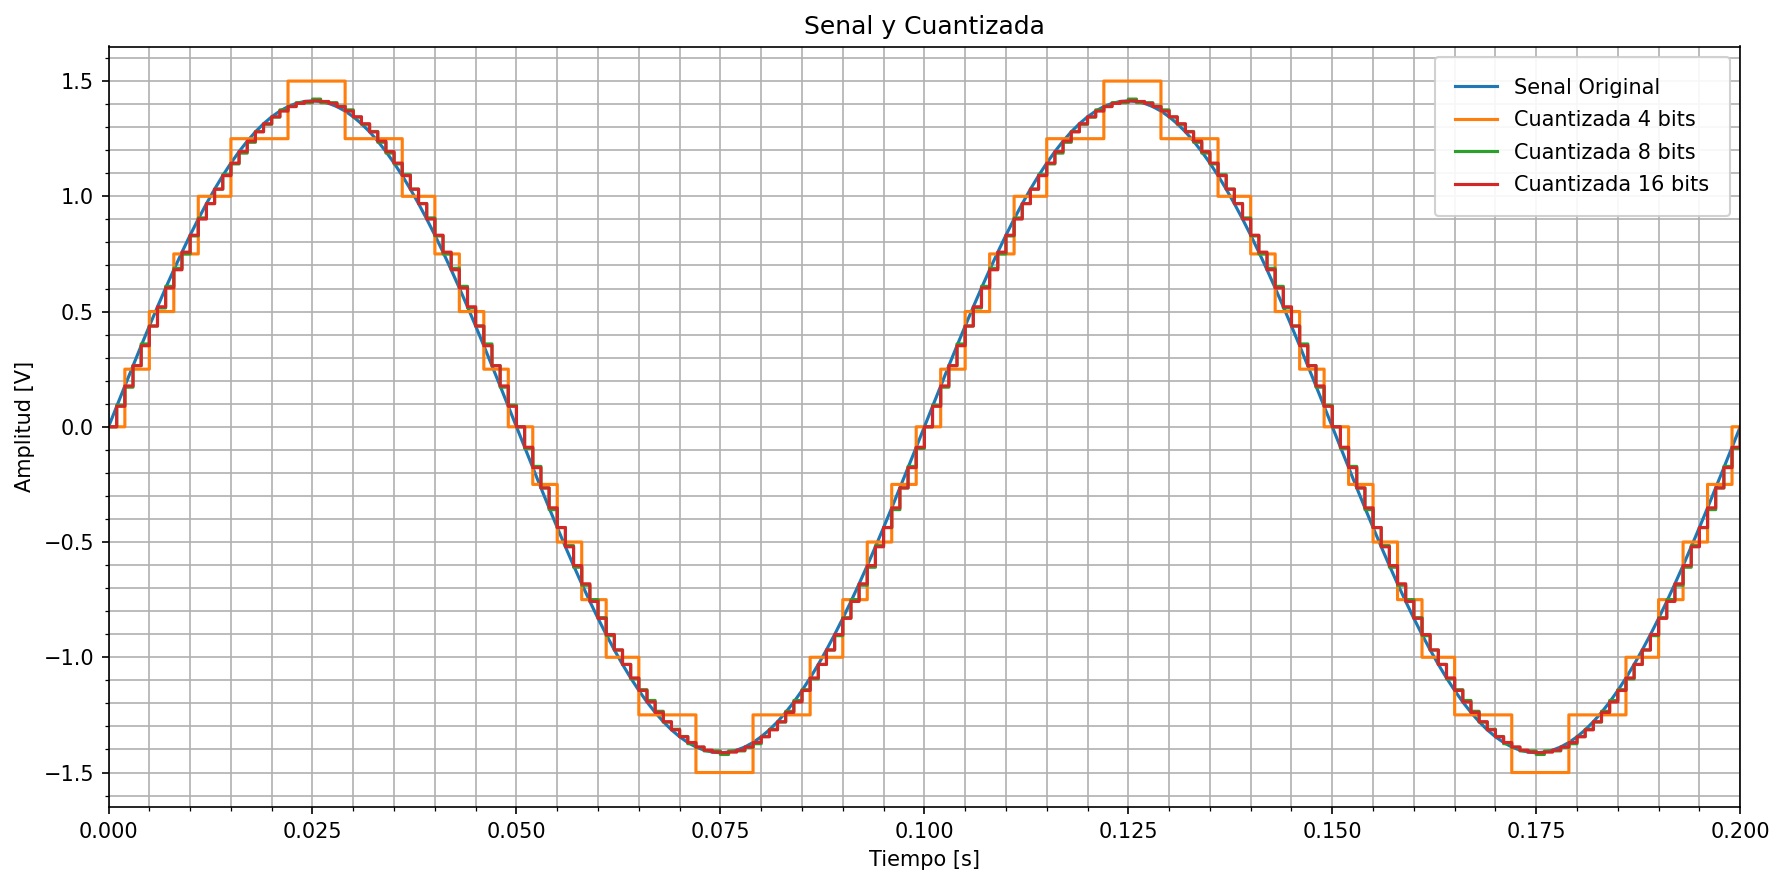

In [3]:
N=1000
fs   = N #Resolucion espectral normalizada
deltaf=fs/N
ff = deltaf*10

t, x = mi_funcion( vmax = np.sqrt(2), dc = 0, ff = ff, ph = 0, nn = N, fs = fs, type_s = 'sine')
VF=2
VFS=2*VF

SQ1 = Quant(VFS,x,4)
SQ2= Quant(VFS,x,8)
SQ3 = Quant(VFS,x,16)

plt.figure(figsize=(12, 6), dpi=150) 
plt.plot(t, x, label="Senal Original")
plt.title("Senal y Cuantizada")
plt.minorticks_on()
plt.plot(t, SQ1, drawstyle='steps-post', label="Cuantizada 4 bits")
plt.plot(t, SQ2, drawstyle='steps-post', label="Cuantizada 8 bits")
plt.plot(t, SQ3, drawstyle='steps-post', label="Cuantizada 16 bits")
plt.xlim([0, 2/ff])
plt.xlabel("Tiempo [s]")  
plt.ylabel("Amplitud [V]")
plt.legend(
    loc='upper right',      
    fontsize=10,          
    framealpha=0.9,        
    borderpad=1,            
    labelspacing=0.6,     
)
plt.grid(which='major', linestyle='-', linewidth=0.8)
plt.grid(which='minor', linestyle='-', linewidth=0.8)
plt.tight_layout()          
plt.show()

#### Analisis senal de error

In [4]:
N=1000
fs   = N #Resolucion espectral normalizada
deltaf=fs/N
ff = deltaf*10

t, x = mi_funcion( vmax = np.sqrt(2), dc = 0, ff = ff, ph = 0, nn = N, fs = fs, type_s = 'sine')
VF=2
VFS=2*VF
B = 8

SQ = Quant(VFS,x,B)
SE = x - SQ

Cuanto=0.015625 para Vref=4 y cantidad de bits = 8


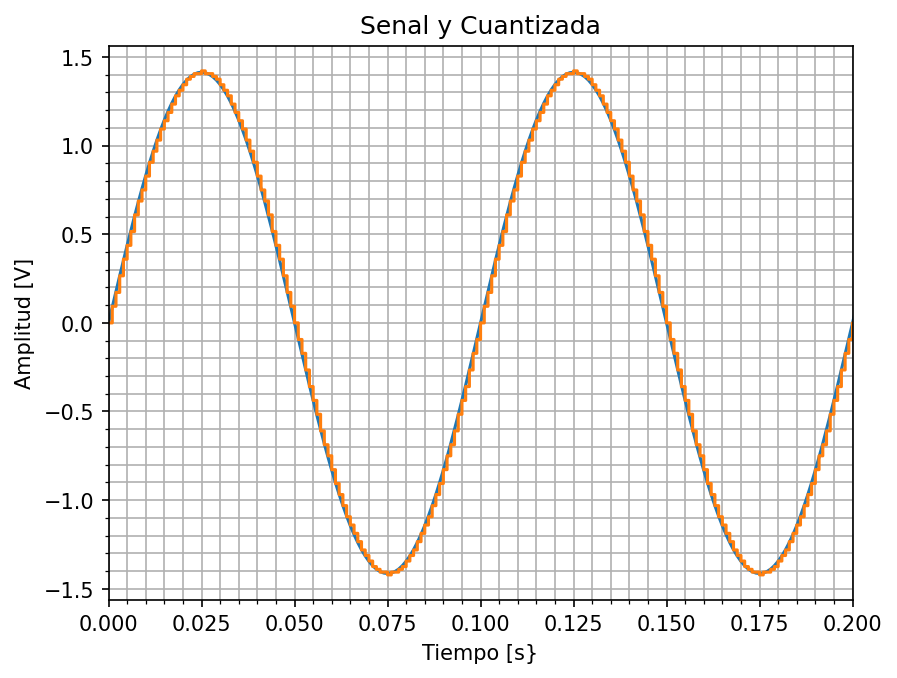

In [5]:
plt.figure(dpi=150)
plt.plot(t,x)
plt.title("Senal y Cuantizada")
plt.minorticks_on()
plt.plot(t,SQ, drawstyle = 'steps-post')
plt.xlim([0, 2/ff])
plt.xlabel("Tiempo [s}")
plt.ylabel("Amplitud [V]")
plt.grid(which = 'major', linestyle = '-', linewidth = 0.8)
plt.grid(which = 'minor', linestyle = '-', linewidth = 0.8)


[ 0.00000000e+00 -2.45103780e-08  5.32008418e-08 ...  5.32008418e-08
 -2.45103780e-08  0.00000000e+00]


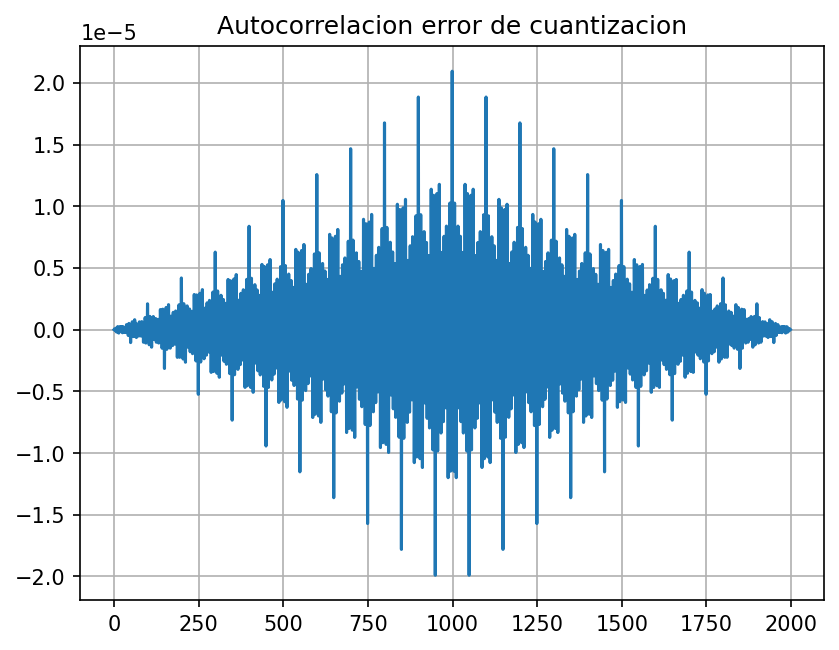

In [6]:
autocorr = np.correlate(SE, SE, mode='full')/N

print(autocorr)
plt.figure(dpi=150)
plt.plot((autocorr))
plt.title("Autocorrelacion error de cuantizacion")
plt.grid()

Se puede ver como la funcion de autocorrelacion de la señal de eror no forma una delta. Por lo tanto es incorrelada

Valor medio de la señal de error -9.573244974525608e-17
Su valor medio teorico deberia ser 0
Varianza de la señal de error 2.0952776573878535e-05

La señal de error deberia estar acotada en estre estos valores -0.0078125 y +0.0078125
Varianza teorica de la señal de error 2.0345052083333332e-05


(0.0, 0.4)

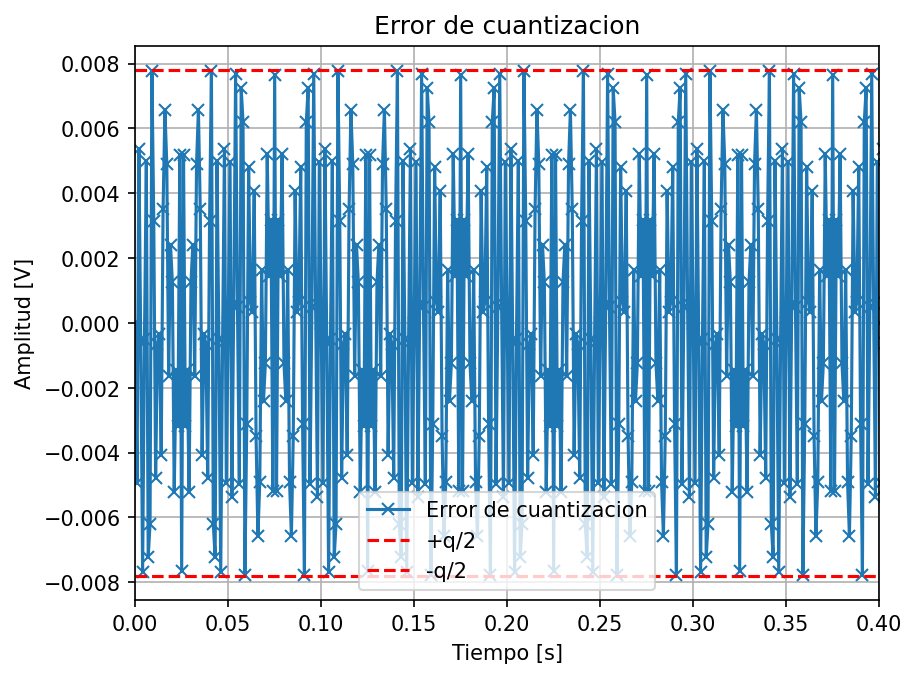

In [7]:
print(f"Valor medio de la señal de error {np.mean(SE)}")
print(f"Su valor medio teorico deberia ser 0")
print(f"Varianza de la señal de error {np.var(SE)}")
print()
q = VFS/(2**B)
print(f"La señal de error deberia estar acotada en estre estos valores {-q/2} y +{q/2}")
print(f"Varianza teorica de la señal de error {q**2/12}")
plt.figure(dpi=150)
plt.title("Error de cuantizacion")
plt.plot(t,SE, marker='x', label= 'Error de cuantizacion')
plt.axhline(y=q/2,  color='red', linestyle='--', label='+q/2')
plt.axhline(y=-q/2, color='red', linestyle='--', label='-q/2')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.legend()
plt.xlim([0, 4/ff])

In [8]:
freq= np.arange(start = 0, stop = fs, step = deltaf)
freq2=np.arange(start = 0, stop = fs, step = deltaf/2)
freq2 = freq2[:-1]
sqf = fft(SQ)
xft = fft(x)
autocorrfft = fft(autocorr)



C:\Users\pedro\AppData\Local\Temp\ipykernel_12576\3007037290.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(freq,20*np.log10(2*np.abs(sqf)/N), marker='x', label= 'quant')


(0.0, 500.0)

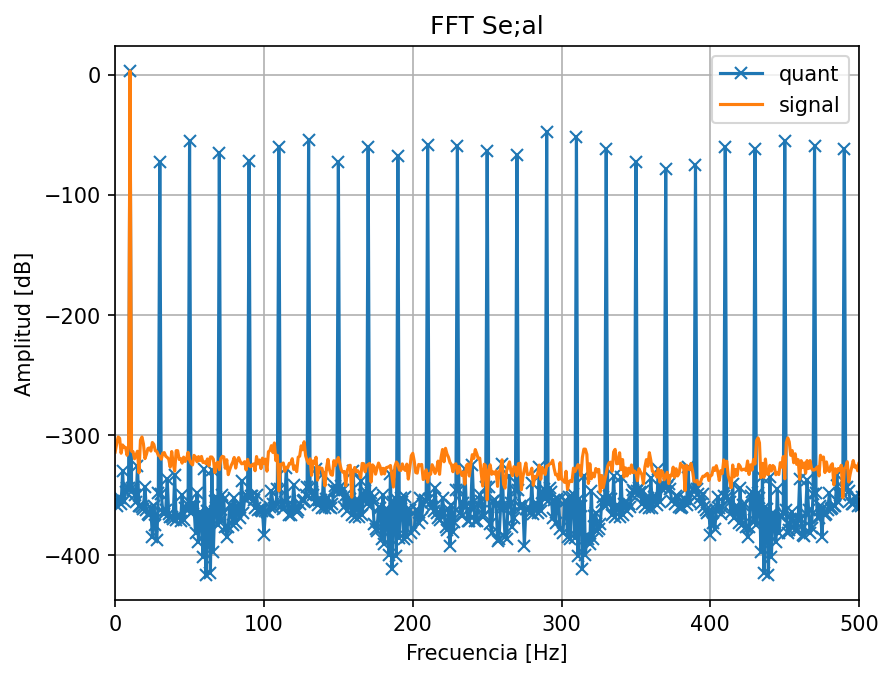

In [9]:
plt.figure(dpi=150)
plt.title("FFT Se;al")
plt.plot(freq,20*np.log10(2*np.abs(sqf)/N), marker='x', label= 'quant')
plt.plot(freq,20*np.log10(2*np.abs(xft)/N), label= 'signal')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.grid()
plt.legend()
plt.xlim([0, fs//2])

(0.0, 500.0)

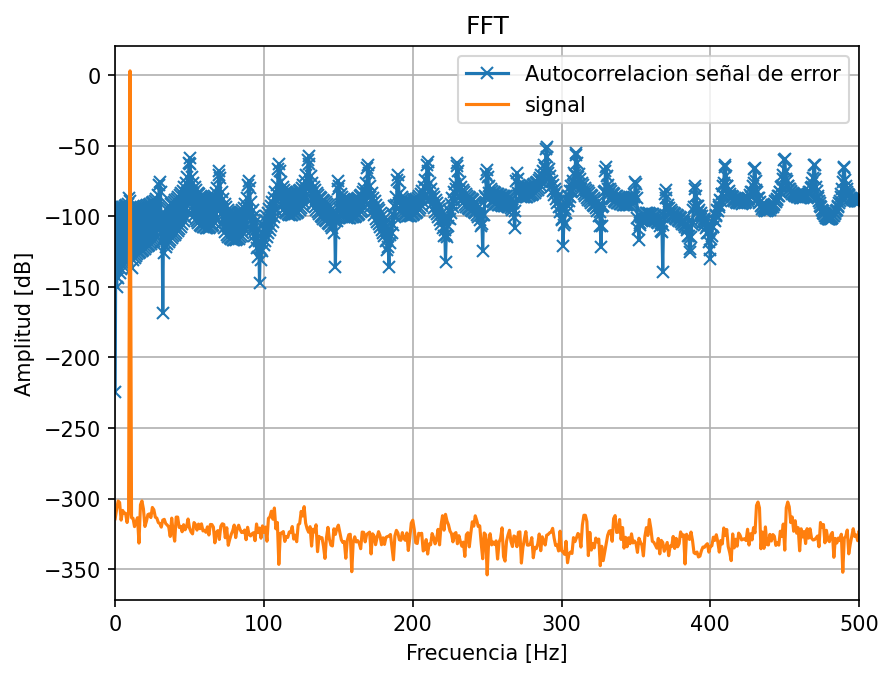

In [10]:


plt.figure(dpi=150)
plt.title("FFT")
plt.plot(freq2,10*np.log10(2*np.abs(autocorrfft)/N), marker='x', label= 'Autocorrelacion señal de error')
plt.plot(freq,20*np.log10(2*np.abs(xft)/N), label='signal')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.grid()
plt.legend()
plt.xlim([0, fs//2])


#### Analisis de senal con ruido

##### SNR 80dB

In [11]:
SNR = 80
tt, xx ,  xx_sine , xx_noise = mi_generador_ruidoso( Psine = 1,R = 1 ,SNRdB=SNR, ff = ff, ph = 0, nn = N, fs = fs)
SQ2 = Quant(VFS,xx,B)


SNR real: 80.407343520 dB
Cuanto=0.015625 para Vref=4 y cantidad de bits = 8


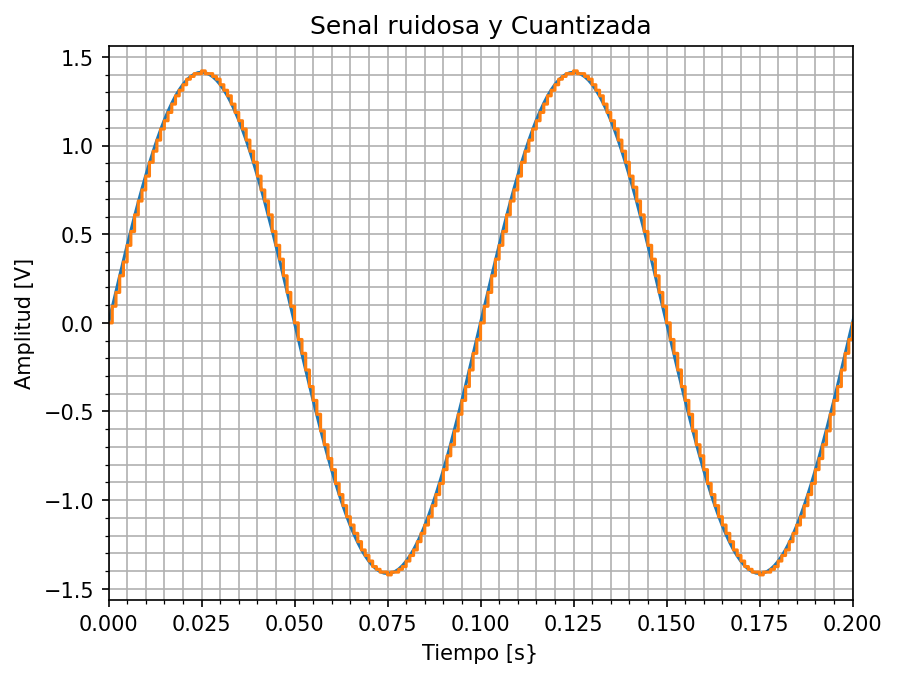

In [12]:
plt.figure(dpi=150)
plt.title("Senal ruidosa y Cuantizada")
plt.minorticks_on()
plt.plot(tt,xx)
plt.plot(tt,SQ2, drawstyle = 'steps-post')
plt.xlabel("Tiempo [s}")
plt.ylabel("Amplitud [V]")
plt.xlim([0, 2/ff])
plt.grid(which = 'major', linestyle = '-', linewidth = 0.8)
plt.grid(which = 'minor', linestyle = '-', linewidth = 0.8)

In [13]:
xxft = fft(xx)
sq2f= fft(SQ2)

se2= xx-SQ2


se2ff = fft(se2)

sn= fft(xx_noise)

(0.0, 500.0)

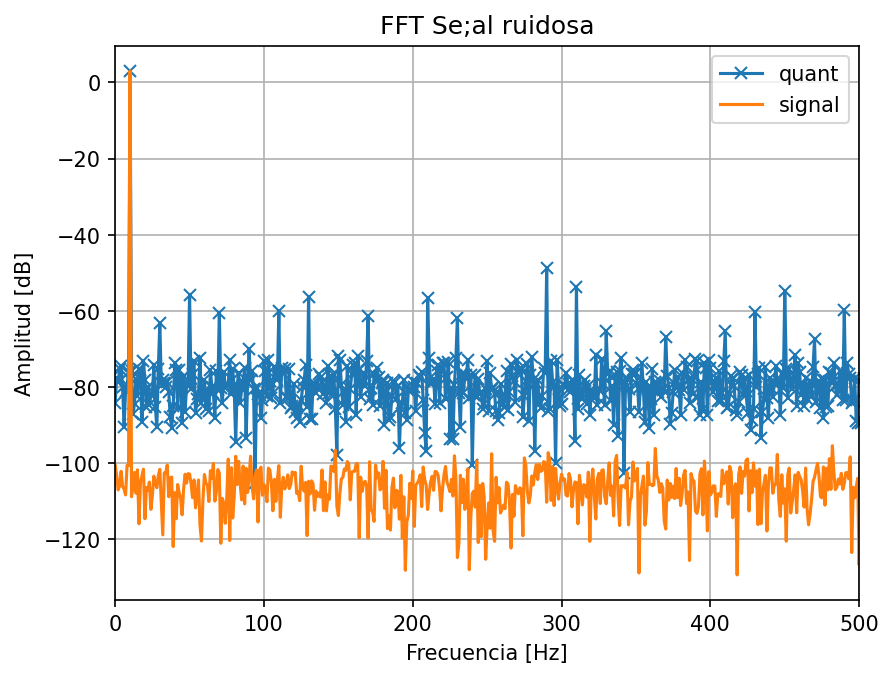

In [14]:
plt.figure(dpi=150)
plt.title("FFT Se;al ruidosa")
plt.plot(freq,20*np.log10(2*np.abs(sq2f)/N), marker='x', label= 'quant')
plt.plot(freq,20*np.log10(2*np.abs(xxft)/N), label= 'signal')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.grid()
plt.legend()
plt.xlim([0, fs//2])

(0.0, 500.0)

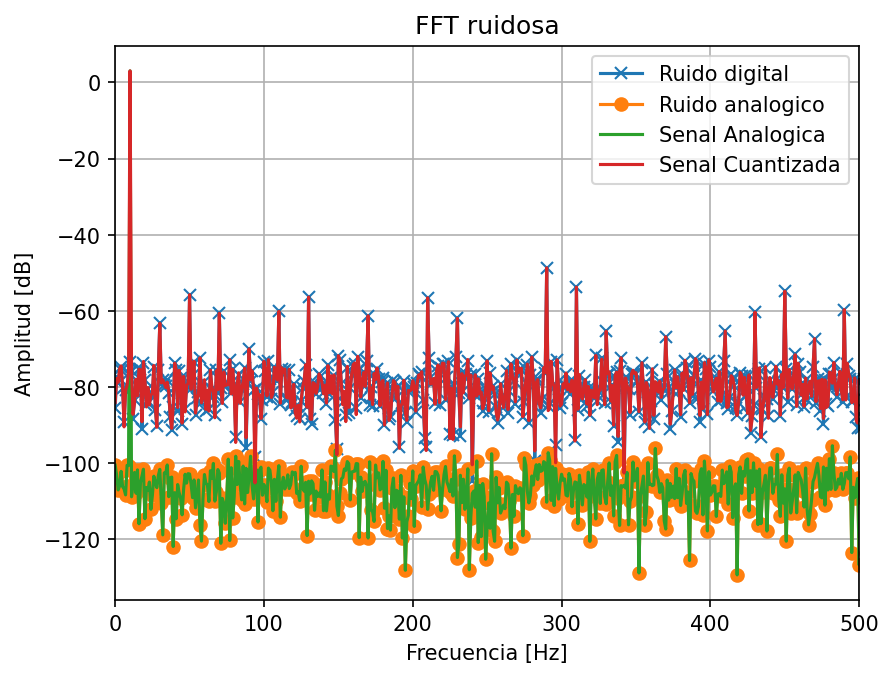

In [15]:
plt.figure(dpi=150)
plt.title("FFT ruidosa")
plt.plot(freq,20*np.log10(2*np.abs(se2ff)/N), marker='x', label= 'Ruido digital')
plt.plot(freq,20*np.log10(2*np.abs(sn)/N), marker='o', label= 'Ruido analogico')
plt.plot(freq,20*np.log10(2*np.abs(xxft)/N), label='Senal Analogica')
plt.plot(freq,20*np.log10(2*np.abs(sq2f)/N), label='Senal Cuantizada')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.grid()
plt.legend()
plt.xlim([0, fs//2])

Se puede ver como en este caso el ruido de la señal cuantizada lo determina el ruido de cuantizacion digital

[ 1.83975882e-10 -2.44904802e-08  5.13063939e-08 ...  5.13063939e-08
 -2.44904802e-08  1.83975882e-10]


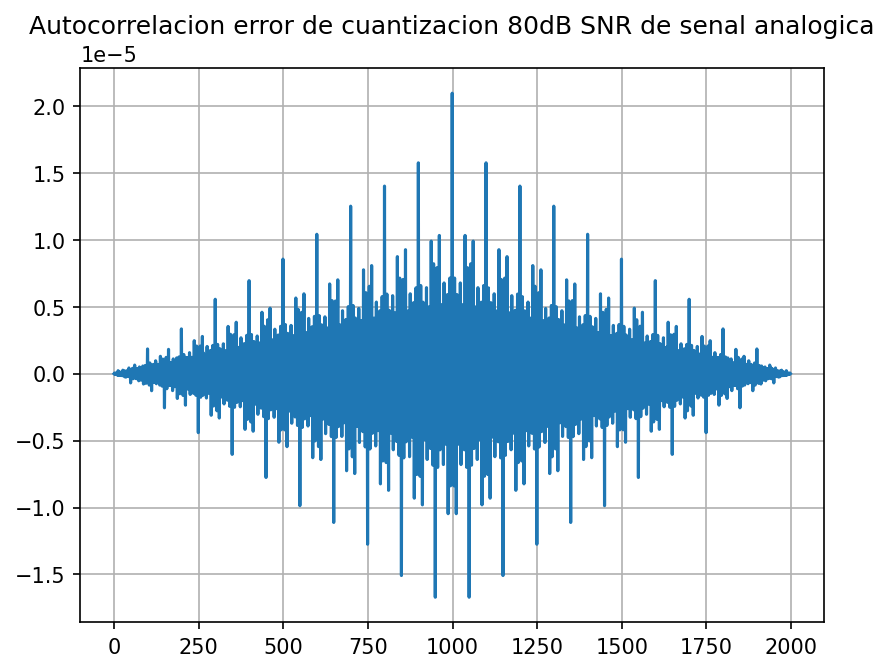

In [16]:
autocorr = np.correlate(se2, se2, mode='full')/N

print(autocorr)
plt.figure(dpi=150)
plt.plot((autocorr))
plt.title("Autocorrelacion error de cuantizacion 80dB SNR de senal analogica")
plt.grid()

In [17]:
freq= np.arange(start = 0, stop = fs, step = deltaf)
freq2=np.arange(start = 0, stop = fs, step = deltaf/2)
freq2 = freq2[:-1]
autocorrfft = fft(autocorr)

(0.0, 500.0)

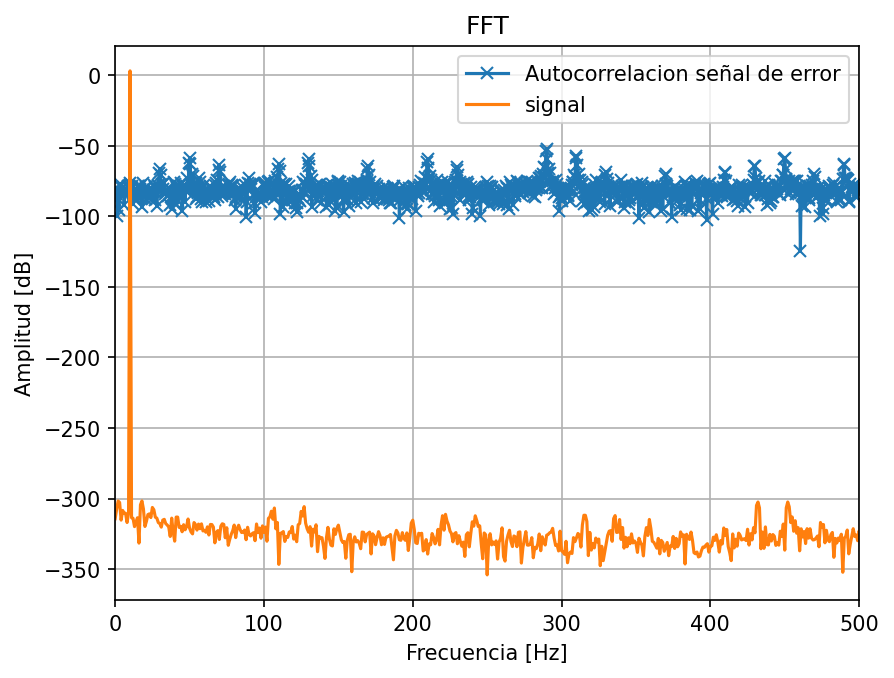

In [18]:

plt.figure(dpi=150)
plt.title("FFT")
plt.plot(freq2,10*np.log10(2*np.abs(autocorrfft)/N), marker='x', label= 'Autocorrelacion señal de error')
plt.plot(freq,20*np.log10(2*np.abs(xft)/N), label='signal')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.grid()
plt.legend()
plt.xlim([0, fs//2])


##### SNR 10dB

In [19]:
SNR = 10
tt, xx ,  xx_sine , xx_noise = mi_generador_ruidoso( Psine = 1,R = 1 ,SNRdB=SNR, ff = ff, ph = 0, nn = N, fs = fs)
SQ2 = Quant(VFS,xx,B)

SNR real: 9.856334445 dB
Cuanto=0.015625 para Vref=4 y cantidad de bits = 8


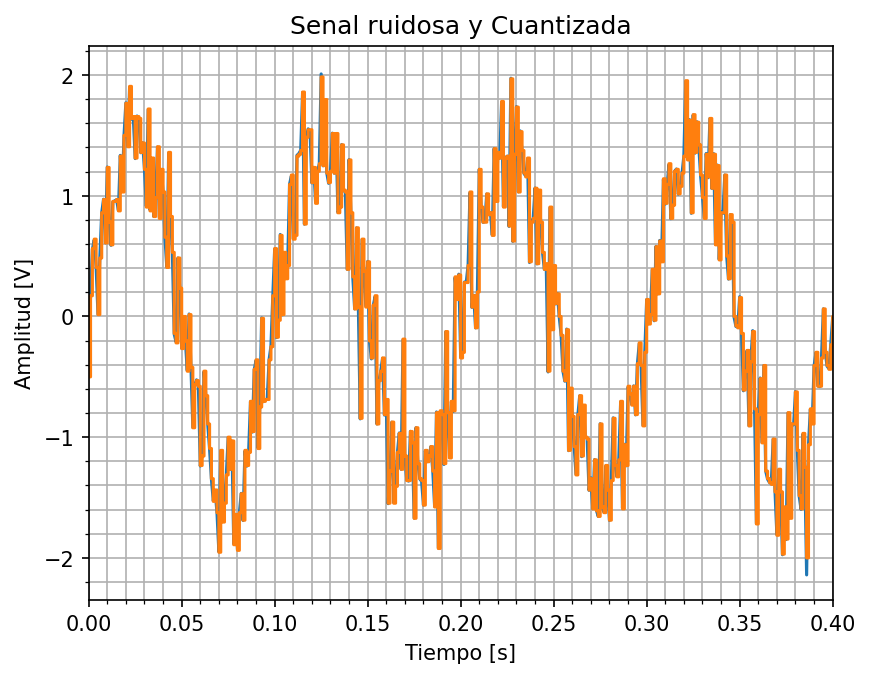

In [20]:
plt.figure(dpi=150)
plt.title("Senal ruidosa y Cuantizada")
plt.minorticks_on()
plt.plot(tt,xx)
plt.plot(tt,SQ2, drawstyle = 'steps-post')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xlim([0, 4/ff])
plt.grid(which = 'major', linestyle = '-', linewidth = 0.8)
plt.grid(which = 'minor', linestyle = '-', linewidth = 0.8)

In [21]:
xxft = fft(xx)
sq2f= fft(SQ2)

se2= xx-SQ2


se2ff = fft(se2)

sn= fft(xx_noise)

(0.0, 500.0)

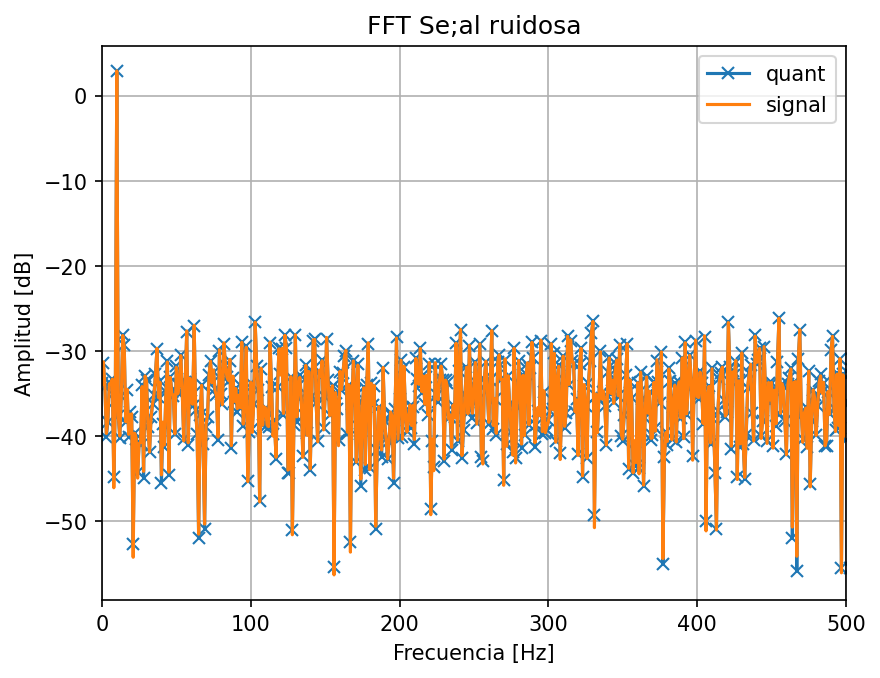

In [22]:
plt.figure(dpi=150)
plt.title("FFT Se;al ruidosa")
plt.plot(freq,20*np.log10(2*np.abs(sq2f)/N), marker='x', label= 'quant')
plt.plot(freq,20*np.log10(2*np.abs(xxft)/N), label= 'signal')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.grid()
plt.legend()
plt.xlim([0, fs//2])

(0.0, 500.0)

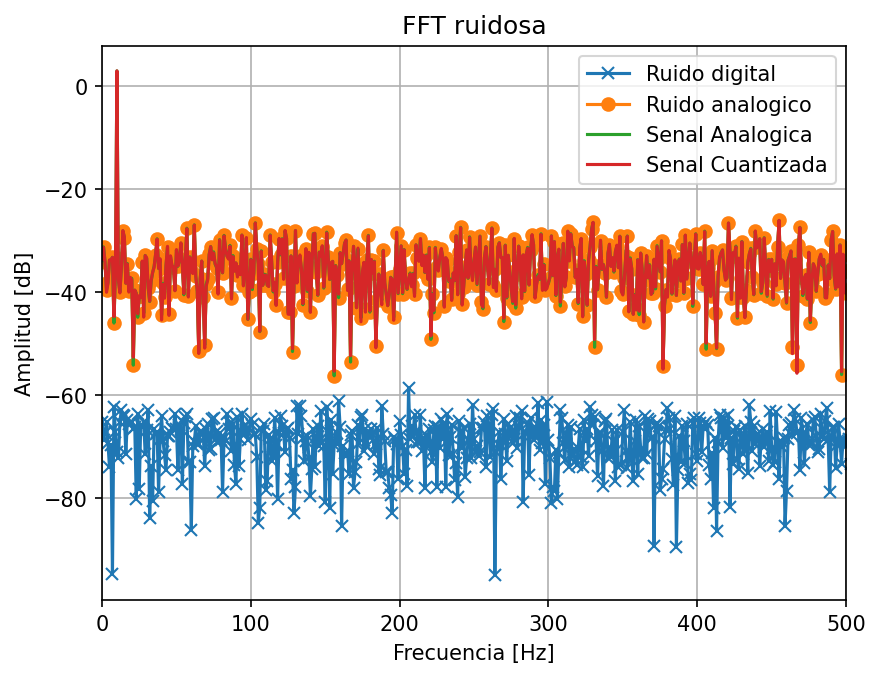

In [23]:
plt.figure(dpi=150)
plt.title("FFT ruidosa")
plt.plot(freq,20*np.log10(2*np.abs(se2ff)/N), marker='x', label= 'Ruido digital')
plt.plot(freq,20*np.log10(2*np.abs(sn)/N), marker='o', label= 'Ruido analogico')
plt.plot(freq,20*np.log10(2*np.abs(xxft)/N), label='Senal Analogica')
plt.plot(freq,20*np.log10(2*np.abs(sq2f)/N), label='Senal Cuantizada')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.grid()
plt.legend()
plt.xlim([0, fs//2])

Se puede ver como en este caso el ruido de la señal cuantizada lo determina el ruido analogico a diferencia del caso anterior

[ 4.00644357e-09  7.32466781e-10 -1.56667726e-08 ... -1.56667726e-08
  7.32466781e-10  4.00644357e-09]


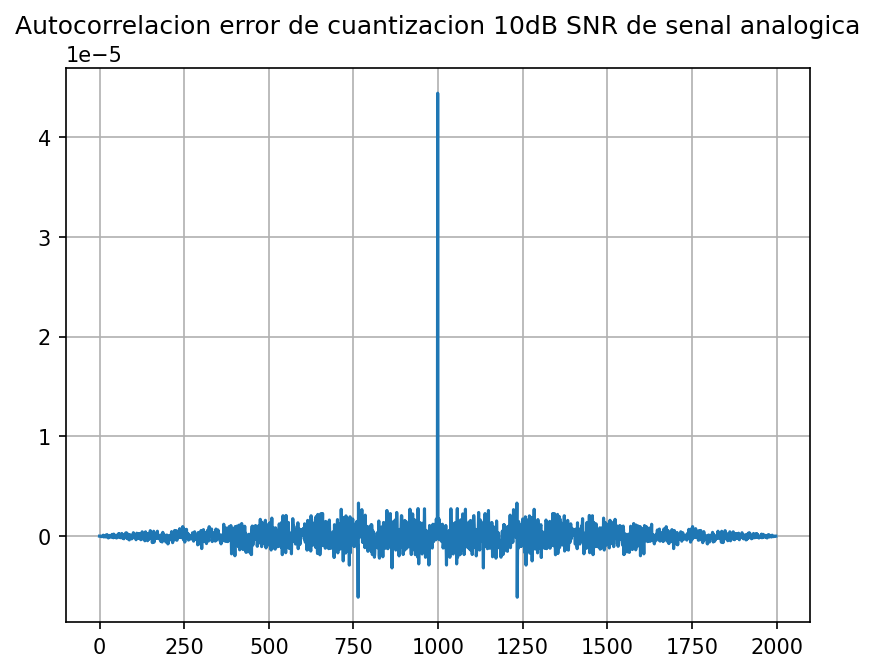

In [24]:
autocorr = np.correlate(se2, se2, mode='full')/N

print(autocorr)
plt.figure(dpi=150)
plt.plot((autocorr))
plt.title("Autocorrelacion error de cuantizacion 10dB SNR de senal analogica")
plt.grid()

Se puede ver como la funcion de autocorrelacion de la señal de error forma una delta en el lag 0. Por lo tanto la señal es correlada consigo misma si no hay lag, en otro caso la señal es incorrelada

In [25]:
freq= np.arange(start = 0, stop = fs, step = deltaf)
freq2=np.arange(start = 0, stop = fs, step = deltaf/2)
freq2 = freq2[:-1]
autocorrfft = fft(autocorr)

(0.0, 500.0)

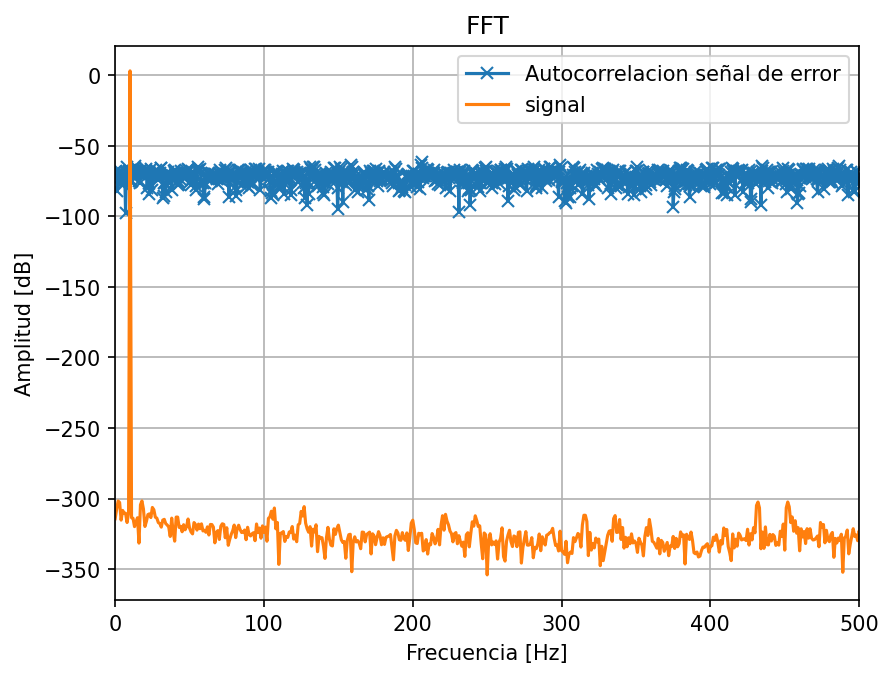

In [26]:

plt.figure(dpi=150)
plt.title("FFT")
plt.plot(freq2,10*np.log10(2*np.abs(autocorrfft)/N), marker='x', label= 'Autocorrelacion señal de error')
plt.plot(freq,20*np.log10(2*np.abs(xft)/N), label='signal')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.grid()
plt.legend()
plt.xlim([0, fs//2])
